# Fusió i Preprocessament de Dades
**TFG – Predicció de Generació d'Energia Renovable amb ML**  
Arnau Ropero Garcia – UAB GCIS 2025/26

Aquest notebook fusiona les dues fonts de dades principals:
- **Generació elèctrica** (ENTSO-E): `generacio_renovable_ES_2023-2025.csv` — columnes `timestamp`, `solar_mw`, `eolica_mw`
- **Meteorologia** (Open-Meteo): `meteo_nacional_ponderada_2023-2025.csv` — mitjana ponderada nacional de 5 estacions

I realitza el pipeline de preprocessament complet fins a obtenir el dataset llest per als models.

---
## 0. Imports i configuració

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades'
PATH_ENTSOE = BASE_PATH + r'\Electricitat\generacio_renovable_ES_2023-2025.csv'
PATH_METEO  = BASE_PATH + r'\Meteo\meteo_nacional_ponderada_2023-2025.csv'
PATH_OUTPUT = BASE_PATH + r'\dataset_final_2023-2025.csv'

print('Paths configurats:')
print(f'  ENTSO-E : {PATH_ENTSOE}')
print(f'  Meteo   : {PATH_METEO}')
print(f'  Output  : {PATH_OUTPUT}')

Paths configurats:
  ENTSO-E : C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\Electricitat\generacio_renovable_ES_2023-2025.csv
  Meteo   : C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\Meteo\meteo_nacional_ponderada_2023-2025.csv
  Output  : C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\dataset_final_2023-2025.csv


---
## 1. Càrrega de les dades

In [2]:
# --- ENTSO-E ---
# Columnes conegudes: timestamp (UTC explícit amb +00:00), solar_mw, eolica_mw
df_gen = pd.read_csv(PATH_ENTSOE)
df_gen['timestamp'] = pd.to_datetime(df_gen['timestamp'], utc=True)
df_gen = df_gen.rename(columns={
    'timestamp' : 'timestamp_utc',
    'solar_mw'  : 'solar_MW',
    'eolica_mw' : 'eolic_MW'
})
df_gen = df_gen.set_index('timestamp_utc').sort_index()

print('=== ENTSO-E – Generació ===')
print(f'  Registres : {len(df_gen)}')
print(f'  Columnes  : {list(df_gen.columns)}')
print(f'  De        : {df_gen.index[0]}')
print(f'  Fins      : {df_gen.index[-1]}')
df_gen.head(3)

=== ENTSO-E – Generació ===
  Registres : 21167
  Columnes  : ['solar_MW', 'eolic_MW']
  De        : 2022-12-31 23:00:00+00:00
  Fins      : 2025-05-31 21:00:00+00:00


,solar_MW,eolic_MW
timestamp_utc,,
2022-12-31 23:00:00+00:00,20.0,6421.0
2023-01-01 00:00:00+00:00,20.0,5747.0
2023-01-01 01:00:00+00:00,20.0,5578.0


In [3]:
# --- Open-Meteo ---
# Els timestamps vénen en hora local Europe/Madrid (sense timezone explícita)
df_meteo = pd.read_csv(PATH_METEO)

# Detectar la columna de temps (primera columna)
time_col = df_meteo.columns[0]
df_meteo[time_col] = pd.to_datetime(df_meteo[time_col])

print('=== Open-Meteo – Meteorologia ===')
print(f'  Registres         : {len(df_meteo)}')
print(f'  Columnes          : {list(df_meteo.columns)}')
print(f'  Columna temps     : "{time_col}"')
print(f'  Exemple timestamp : {df_meteo[time_col].iloc[0]}')

=== Open-Meteo – Meteorologia ===
  Registres         : 21168
  Columnes          : ['time', 'shortwave_radiation_Wm2', 'direct_radiation_Wm2', 'diffuse_radiation_Wm2', 'cloud_cover_pct', 'wind_speed_100m_ms', 'wind_speed_10m_ms', 'wind_gusts_10m_ms', 'temperature_2m_C', 'precipitation_mm']
  Columna temps     : "time"
  Exemple timestamp : 2023-01-01 00:00:00


In [4]:
# Conversió hora local Europe/Madrid → UTC
# Gestió robusta dels canvis d'hora (DST):
#   - Hores ambigues (tardor, ex. 29-oct 02:00 apareix dues vegades): assumim CEST
#   - Hores inexistents (primavera): avancem 1h
tz_madrid = pytz.timezone('Europe/Madrid')

def localitzar_segur(ts):
    try:
        return tz_madrid.localize(ts, is_dst=None)
    except pytz.exceptions.AmbiguousTimeError:
        return tz_madrid.localize(ts, is_dst=True)
    except pytz.exceptions.NonExistentTimeError:
        return tz_madrid.localize(ts + pd.Timedelta('1h'), is_dst=False)

print('Convertint timestamps a UTC (pot trigar uns segons)...')
timestamps_utc = [localitzar_segur(ts).astimezone(pytz.utc)
                  for ts in df_meteo[time_col].tolist()]

df_meteo[time_col] = pd.DatetimeIndex(timestamps_utc, tz='UTC')
df_meteo = df_meteo.rename(columns={time_col: 'timestamp_utc'})
df_meteo = df_meteo.set_index('timestamp_utc').sort_index()

print('Conversió completada ✓')
print(f'  De   : {df_meteo.index[0]}')
print(f'  Fins : {df_meteo.index[-1]}')
df_meteo.head(3)

Convertint timestamps a UTC (pot trigar uns segons)...
Conversió completada ✓
  De   : 2022-12-31 23:00:00+00:00
  Fins : 2025-05-31 21:00:00+00:00


,shortwave_radiation_Wm2,direct_radiation_Wm2,diffuse_radiation_Wm2,cloud_cover_pct,wind_speed_100m_ms,wind_speed_10m_ms,wind_gusts_10m_ms,temperature_2m_C,precipitation_mm
timestamp_utc,,,,,,,,,
2022-12-31 23:00:00+00:00,0.0,0.0,0.0,38.90,7.4825,4.5905,7.755,9.34,0.14
2023-01-01 00:00:00+00:00,0.0,0.0,0.0,32.00,7.3250,4.4720,7.905,8.82,0.14
2023-01-01 01:00:00+00:00,0.0,0.0,0.0,19.45,7.4715,4.3715,7.595,8.82,0.18


---
## 2. Verificació de la cobertura temporal

In [5]:
print('=== Comparació de rangs temporals ===')
print(f'ENTSO-E : {df_gen.index.min()}  →  {df_gen.index.max()}  ({len(df_gen)} registres)')
print(f'Meteo   : {df_meteo.index.min()}  →  {df_meteo.index.max()}  ({len(df_meteo)} registres)')

inici_comu = max(df_gen.index.min(), df_meteo.index.min())
fi_comu    = min(df_gen.index.max(), df_meteo.index.max())
print(f'\nRang comú: {inici_comu}  →  {fi_comu}')

=== Comparació de rangs temporals ===
ENTSO-E : 2022-12-31 23:00:00+00:00  →  2025-05-31 21:00:00+00:00  (21167 registres)
Meteo   : 2022-12-31 23:00:00+00:00  →  2025-05-31 21:00:00+00:00  (21168 registres)

Rang comú: 2022-12-31 23:00:00+00:00  →  2025-05-31 21:00:00+00:00


---
## 3. Neteja de les dades de generació

In [6]:
print('Estadístiques bàsiques de generació:')
print(df_gen.describe().round(1))

Estadístiques bàsiques de generació:
       solar_MW  eolic_MW
count   21167.0   21167.0
mean     5002.1    6854.1
std      6106.3    4046.4
min         0.0     190.0
25%       107.5    3578.5
50%       744.0    6146.0
75%     10207.0    9497.5
max     21280.0   20718.0


In [7]:
# Valors negatius → 0 (artefacte puntual d'ENTSO-E, sense sentit físic)
neg_solar = (df_gen['solar_MW'] < 0).sum()
neg_eolic = (df_gen['eolic_MW'] < 0).sum()
print(f'Valors negatius solar: {neg_solar}')
print(f'Valors negatius eòlic: {neg_eolic}')

df_gen['solar_MW'] = df_gen['solar_MW'].clip(lower=0)
df_gen['eolic_MW'] = df_gen['eolic_MW'].clip(lower=0)
print('Clip a 0 aplicat ✓')

Valors negatius solar: 0
Valors negatius eòlic: 0
Clip a 0 aplicat ✓


In [8]:
# Valors nuls
nulls_gen = df_gen.isna().sum()
print('Nuls per columna (generació):')
print(nulls_gen)

if nulls_gen.sum() > 0:
    print('\nInterpolació lineal (limit=3h)...')
    df_gen = df_gen.interpolate(method='time', limit=3)
    print(f'Nuls restants: {df_gen.isna().sum().sum()}')
else:
    print('\nCap valor nul ✓')

Nuls per columna (generació):
solar_MW    0
eolic_MW    0
dtype: int64

Cap valor nul ✓


---
## 4. Neteja de les dades meteorològiques

In [9]:
print('Columnes meteorologia i nuls:')
for col in df_meteo.columns:
    print(f'  {col}  →  nulls: {df_meteo[col].isna().sum()}')

Columnes meteorologia i nuls:
  shortwave_radiation_Wm2  →  nulls: 0
  direct_radiation_Wm2  →  nulls: 0
  diffuse_radiation_Wm2  →  nulls: 0
  cloud_cover_pct  →  nulls: 0
  wind_speed_100m_ms  →  nulls: 0
  wind_speed_10m_ms  →  nulls: 0
  wind_gusts_10m_ms  →  nulls: 0
  temperature_2m_C  →  nulls: 0
  precipitation_mm  →  nulls: 0


In [10]:
nulls_meteo = df_meteo.isna().sum().sum()
if nulls_meteo > 0:
    print(f'Total nuls: {nulls_meteo} → interpolació lineal...')
    df_meteo = df_meteo.interpolate(method='time', limit=3)
    print(f'Nuls restants: {df_meteo.isna().sum().sum()}')
else:
    print('Cap valor nul al dataset meteorològic ✓')

Cap valor nul al dataset meteorològic ✓


In [11]:
# Control de qualitat: irradiació solar nocturna ha de ser ~0
if 'shortwave_radiation' in df_meteo.columns:
    idx_local_q = df_meteo.index.tz_convert('Europe/Madrid')
    mask_nit = idx_local_q.hour.isin([0, 1, 2, 3, 4, 22, 23])
    max_rad_nit = df_meteo.loc[mask_nit, 'shortwave_radiation'].max()
    print(f'Irradiació màxima en hores nocturnes (00–04h, 22–23h): {max_rad_nit:.2f} W/m²')
    print('  → Comportament nocturn coherent ✓' if max_rad_nit < 10 else '  → Atenció: valors inusuals!')

---
## 5. Fusió dels datasets

In [12]:
# Inner join per timestamp_utc
df = df_gen.join(df_meteo, how='inner')

print('=== Resultat de la fusió ===')
print(f'Registres ENTSO-E  : {len(df_gen)}')
print(f'Registres Meteo    : {len(df_meteo)}')
print(f'Registres fusionats: {len(df)}')
print(f'Columnes totals    : {len(df.columns)}')
print(f'De   : {df.index[0]}')
print(f'Fins : {df.index[-1]}')

perduts = len(df_gen) - len(df)
if perduts > 0:
    print(f'\nAtenció: {perduts} registres sense correspondència.')
else:
    print('\nFusió sense pèrdua de registres ✓')

=== Resultat de la fusió ===
Registres ENTSO-E  : 21167
Registres Meteo    : 21168
Registres fusionats: 21168
Columnes totals    : 11
De   : 2022-12-31 23:00:00+00:00
Fins : 2025-05-31 21:00:00+00:00

Fusió sense pèrdua de registres ✓


In [13]:
# Verificar continuïtat temporal (sense gaps > 1h)
diffs = df.index.to_series().diff().dropna()
gaps = diffs[diffs > pd.Timedelta('1h')]
print(f'Gaps > 1h detectats: {len(gaps)}')
if len(gaps) > 0:
    for ts, gap in gaps.items():
        print(f'  {ts}  →  gap de {gap}')
else:
    print('Sèrie temporal contínua ✓')

Gaps > 1h detectats: 2
  2023-10-29 02:00:00+00:00  →  gap de 0 days 02:00:00
  2024-10-27 02:00:00+00:00  →  gap de 0 days 02:00:00


In [14]:
df.head()

,solar_MW,eolic_MW,shortwave_radiation_Wm2,direct_radiation_Wm2,diffuse_radiation_Wm2,cloud_cover_pct,wind_speed_100m_ms,wind_speed_10m_ms,wind_gusts_10m_ms,temperature_2m_C,precipitation_mm
timestamp_utc,,,,,,,,,,,
2022-12-31 23:00:00+00:00,20.0,6421.0,0.0,0.0,0.0,38.90,7.4825,4.5905,7.755,9.34,0.14
2023-01-01 00:00:00+00:00,20.0,5747.0,0.0,0.0,0.0,32.00,7.3250,4.4720,7.905,8.82,0.14
2023-01-01 01:00:00+00:00,20.0,5578.0,0.0,0.0,0.0,19.45,7.4715,4.3715,7.595,8.82,0.18
2023-01-01 02:00:00+00:00,20.0,5400.0,0.0,0.0,0.0,63.75,7.7065,4.4300,7.840,8.62,0.10
2023-01-01 03:00:00+00:00,20.0,4766.0,0.0,0.0,0.0,61.65,7.4850,4.4635,7.965,8.42,0.12


---
## 6. Creació de variables derivades

### 6.1 Variables de calendari (en hora local)

In [15]:
idx_local = df.index.tz_convert('Europe/Madrid')

df['hora']              = idx_local.hour
df['dia_setmana']       = idx_local.dayofweek   # 0=Dilluns, 6=Diumenge
df['mes']               = idx_local.month
df['dia_any']           = idx_local.dayofyear
df['any']               = idx_local.year
df['is_cap_de_setmana'] = (idx_local.dayofweek >= 5).astype(int)

print('Variables de calendari creades ✓')
df[['hora','dia_setmana','mes','dia_any','any','is_cap_de_setmana']].head(5)

Variables de calendari creades ✓


,hora,dia_setmana,mes,dia_any,any,is_cap_de_setmana
timestamp_utc,,,,,,
2022-12-31 23:00:00+00:00,0,6,1,1,2023,1
2023-01-01 00:00:00+00:00,1,6,1,1,2023,1
2023-01-01 01:00:00+00:00,2,6,1,1,2023,1
2023-01-01 02:00:00+00:00,3,6,1,1,2023,1
2023-01-01 03:00:00+00:00,4,6,1,1,2023,1


### 6.2 Festius nacionals espanyols 2023–2025

In [16]:
festius = [
    # 2023
    '2023-01-06','2023-04-07','2023-04-10','2023-05-01','2023-08-15',
    '2023-10-12','2023-11-01','2023-12-06','2023-12-08','2023-12-25',
    # 2024
    '2024-01-01','2024-01-06','2024-03-29','2024-04-01','2024-05-01',
    '2024-08-15','2024-10-12','2024-11-01','2024-12-06','2024-12-25',
    # 2025
    '2025-01-01','2025-01-06','2025-04-18','2025-04-21','2025-05-01',
    '2025-08-15','2025-10-12','2025-11-01','2025-12-08','2025-12-25',
]
festius_set  = set(pd.to_datetime(festius).strftime('%Y-%m-%d'))
dates_locals = idx_local.strftime('%Y-%m-%d')
df['is_festiu'] = [1 if d in festius_set else 0 for d in dates_locals]

print(f'Hores marcades com a festiu: {df["is_festiu"].sum()} (esperats ~{len(festius)*24})')

Hores marcades com a festiu: 600 (esperats ~720)


### 6.3 Lags temporals

In [17]:
# Lags de generació: 1h, 24h, 168h (1 setmana)
for lag in [1, 24, 168]:
    df[f'solar_MW_lag{lag}h'] = df['solar_MW'].shift(lag)
    df[f'eolic_MW_lag{lag}h'] = df['eolic_MW'].shift(lag)

# Lags de variables meteorològiques principals: 1h, 24h
vars_lag = ['shortwave_radiation', 'wind_speed_100m', 'temperature_2m']
for var in vars_lag:
    if var in df.columns:
        for lag in [1, 24]:
            df[f'{var}_lag{lag}h'] = df[var].shift(lag)

lag_cols = [c for c in df.columns if 'lag' in c]
print(f'Columnes lag creades: {len(lag_cols)}')
for c in lag_cols:
    print(f'  {c}')

Columnes lag creades: 6
  solar_MW_lag1h
  eolic_MW_lag1h
  solar_MW_lag24h
  eolic_MW_lag24h
  solar_MW_lag168h
  eolic_MW_lag168h


### 6.4 Eliminar files inicials amb NaN (lags de 168h)

In [18]:
n_before   = len(df)
cols_lag168 = [c for c in df.columns if 'lag168' in c]
df = df.dropna(subset=cols_lag168)

print(f'Files eliminades per NaN en lag168h: {n_before - len(df)}')
print(f'Registres finals : {len(df)}')
print(f'Rang             : {df.index[0]}  →  {df.index[-1]}')
print(f'Nuls totals      : {df.isna().sum().sum()}')
if df.isna().sum().sum() == 0:
    print('Dataset complet, sense valors nuls ✓')

Files eliminades per NaN en lag168h: 168
Registres finals : 21000
Rang             : 2023-01-07 23:00:00+00:00  →  2025-05-31 21:00:00+00:00
Nuls totals      : 0
Dataset complet, sense valors nuls ✓


---
## 7. Divisió temporal

| Conjunt | Període | Propòsit |
|---------|---------|----------|
| **Train** | 2023 (setmana 2) → 2024-12-31 | Entrenament dels models |
| **Validation** | 2025-01-01 → 2025-03-31 | Ajust d'hiperparàmetres |
| **Test** | 2025-04-01 → 2025-05-31 | Avaluació final (inclou apagada 28-abr) |

In [19]:
INICI_VAL  = pd.Timestamp('2025-01-01 00:00:00', tz='UTC')
INICI_TEST = pd.Timestamp('2025-04-01 00:00:00', tz='UTC')
FI_TEST    = pd.Timestamp('2025-05-31 23:00:00', tz='UTC')

df_train = df[df.index < INICI_VAL]
df_val   = df[(df.index >= INICI_VAL) & (df.index < INICI_TEST)]
df_test  = df[(df.index >= INICI_TEST) & (df.index <= FI_TEST)]

print('=== Divisió temporal ===')
print(f'Train      : {len(df_train):>6,} registres  |  {df_train.index[0].date()} → {df_train.index[-1].date()}')
print(f'Validation : {len(df_val):>6,} registres  |  {df_val.index[0].date()} → {df_val.index[-1].date()}')
print(f'Test       : {len(df_test):>6,} registres  |  {df_test.index[0].date()} → {df_test.index[-1].date()}')
print(f'Total      : {len(df_train)+len(df_val)+len(df_test):>6,} registres')

=== Divisió temporal ===
Train      : 17,377 registres  |  2023-01-07 → 2024-12-31
Validation :  2,161 registres  |  2025-01-01 → 2025-03-31
Test       :  1,462 registres  |  2025-04-01 → 2025-05-31
Total      : 21,000 registres


---
## 8. Visualitzacions de verificació

### 8.1 Sèries temporals completes (train / val / test)

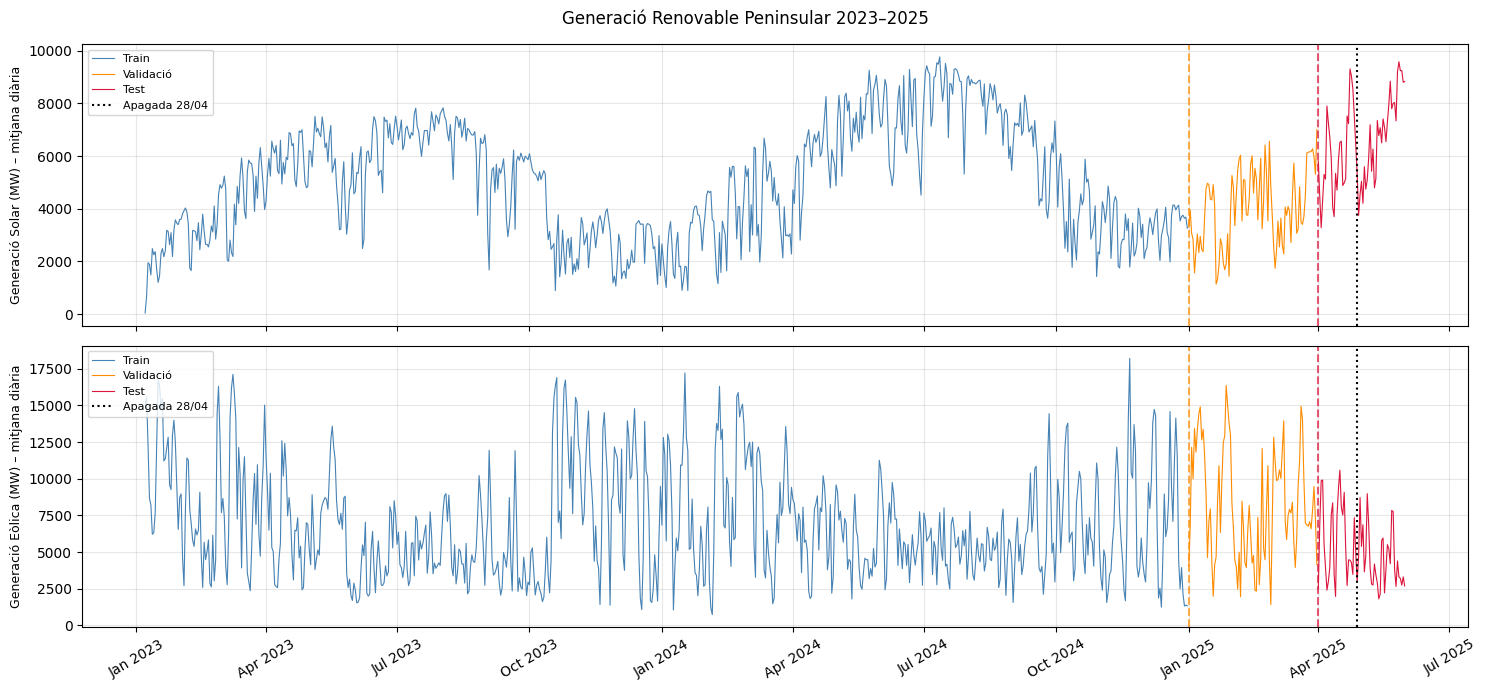

Figura guardada: series_temporals_generacio.png


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
df_diari = df[['solar_MW','eolic_MW']].resample('D').mean()

configs = [
    ('solar_MW', 'Generació Solar (MW) – mitjana diària'),
    ('eolic_MW', 'Generació Eòlica (MW) – mitjana diària'),
]

for ax, (col, titol) in zip(axes, configs):
    s = df_diari[col]
    s_train = s[s.index < INICI_VAL]
    s_val   = s[(s.index >= INICI_VAL) & (s.index < INICI_TEST)]
    s_test  = s[s.index >= INICI_TEST]
    ax.plot(s_train.index, s_train.values, color='steelblue',   lw=0.8, label='Train')
    ax.plot(s_val.index,   s_val.values,   color='darkorange',  lw=0.8, label='Validació')
    ax.plot(s_test.index,  s_test.values,  color='crimson',     lw=0.8, label='Test')
    ax.axvline(INICI_VAL,  color='darkorange', ls='--', alpha=0.7)
    ax.axvline(INICI_TEST, color='crimson',    ls='--', alpha=0.7)
    ax.axvline(pd.Timestamp('2025-04-28', tz='UTC'), color='black', ls=':', lw=1.5, label='Apagada 28/04')
    ax.set_ylabel(titol, fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.suptitle('Generació Renovable Peninsular 2023–2025', fontsize=12)
plt.tight_layout()
plt.savefig('series_temporals_generacio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: series_temporals_generacio.png')

### 8.2 Zoom a l'apagada (20 abril – 5 maig 2025)

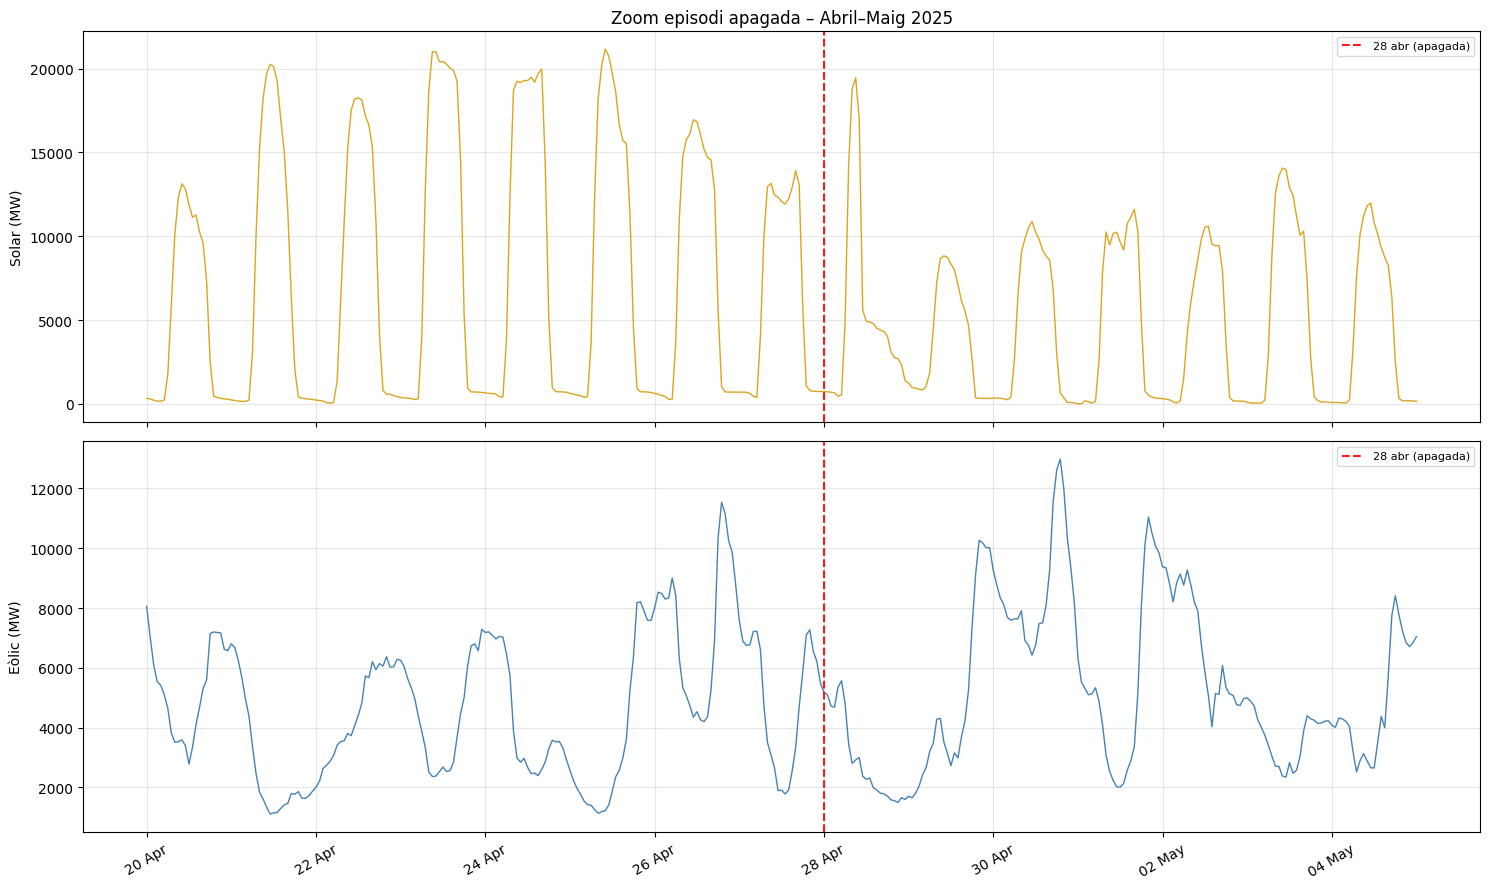

Figura guardada: zoom_apagada_abril2025.png


In [21]:
zoom_ini = pd.Timestamp('2025-04-20', tz='UTC')
zoom_fi  = pd.Timestamp('2025-05-05', tz='UTC')
dz = df.loc[zoom_ini:zoom_fi]

n_panels = 3 if 'shortwave_radiation' in dz.columns else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(15, 9), sharex=True)

axes[0].plot(dz.index, dz['solar_MW'], color='goldenrod',   lw=1)
axes[0].set_ylabel('Solar (MW)')
axes[0].set_title('Zoom episodi apagada – Abril–Maig 2025')

axes[1].plot(dz.index, dz['eolic_MW'], color='steelblue',   lw=1)
axes[1].set_ylabel('Eòlic (MW)')

if n_panels == 3:
    axes[2].plot(dz.index, dz['shortwave_radiation'], color='darkorange', lw=1)
    axes[2].set_ylabel('Irradiació (W/m²)')

apagada = pd.Timestamp('2025-04-28', tz='UTC')
for ax in axes:
    ax.axvline(apagada, color='red', ls='--', lw=1.5, alpha=0.9, label='28 abr (apagada)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('zoom_apagada_abril2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: zoom_apagada_abril2025.png')

### 8.3 Matriu de correlacions

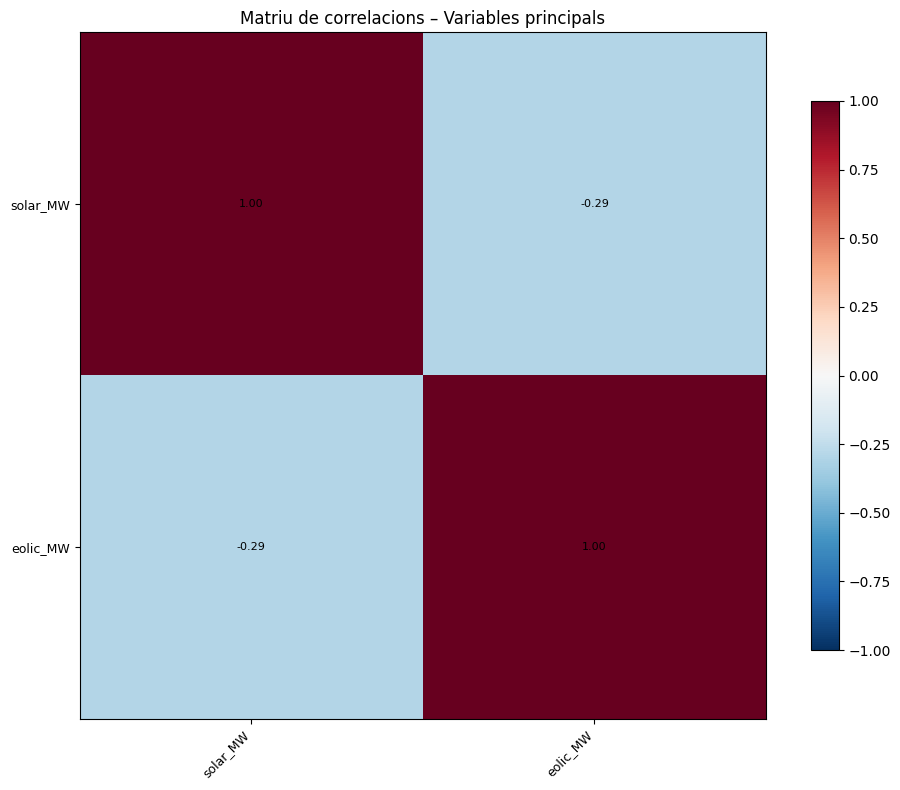

Figura guardada: matriu_correlacions.png


In [22]:
vars_corr = ['solar_MW', 'eolic_MW'] + [
    c for c in ['shortwave_radiation','direct_radiation','diffuse_radiation',
                'wind_speed_100m','wind_speed_10m','cloud_cover',
                'temperature_2m','precipitation']
    if c in df.columns
]

corr = df[vars_corr].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Matriu de correlacions – Variables principals', fontsize=12)
plt.tight_layout()
plt.savefig('matriu_correlacions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: matriu_correlacions.png')

---
## 9. Resum estadístic del dataset final

In [23]:
print('=' * 60)
print('RESUM DEL DATASET FINAL')
print('=' * 60)
print(f'Registres totals    : {len(df):,}')
print(f'Columnes totals     : {len(df.columns)}')
print(f'Rang temporal (UTC) : {df.index[0]}  →  {df.index[-1]}')
print(f'Nuls totals         : {df.isna().sum().sum()}')
print()
print('Distribució per conjunt:')
print(f'  Train      : {len(df_train):>6,} registres ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Validació  : {len(df_val):>6,} registres ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test       : {len(df_test):>6,} registres ({len(df_test)/len(df)*100:.1f}%)')
print()
print('Estadístiques de les variables target:')
print(df[['solar_MW','eolic_MW']].describe().round(1))

RESUM DEL DATASET FINAL
Registres totals    : 21,000
Columnes totals     : 24
Rang temporal (UTC) : 2023-01-07 23:00:00+00:00  →  2025-05-31 21:00:00+00:00
Nuls totals         : 0

Distribució per conjunt:
  Train      : 17,377 registres (82.7%)
  Validació  :  2,161 registres (10.3%)
  Test       :  1,462 registres (7.0%)

Estadístiques de les variables target:
       solar_MW  eolic_MW
count   21000.0   21000.0
mean     5026.9    6869.7
std      6118.9    4044.1
min         0.0     190.0
25%       111.0    3602.8
50%       750.0    6172.5
75%     10263.5    9509.0
max     21280.0   20718.0


In [24]:
print('Totes les columnes del dataset final:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')

Totes les columnes del dataset final:
   1. solar_MW
   2. eolic_MW
   3. shortwave_radiation_Wm2
   4. direct_radiation_Wm2
   5. diffuse_radiation_Wm2
   6. cloud_cover_pct
   7. wind_speed_100m_ms
   8. wind_speed_10m_ms
   9. wind_gusts_10m_ms
  10. temperature_2m_C
  11. precipitation_mm
  12. hora
  13. dia_setmana
  14. mes
  15. dia_any
  16. any
  17. is_cap_de_setmana
  18. is_festiu
  19. solar_MW_lag1h
  20. eolic_MW_lag1h
  21. solar_MW_lag24h
  22. eolic_MW_lag24h
  23. solar_MW_lag168h
  24. eolic_MW_lag168h


---
## 10. Exportació del dataset final

In [25]:
# Afegir columna 'split' per facilitar la feina als models
df['split'] = 'train'
df.loc[df.index >= INICI_VAL,  'split'] = 'validation'
df.loc[df.index >= INICI_TEST, 'split'] = 'test'

df.to_csv(PATH_OUTPUT)
print(f'Dataset exportat a:')
print(f'  {PATH_OUTPUT}')
print(f'  {len(df):,} registres  |  {len(df.columns)} columnes')

# Verificació ràpida
df_check = pd.read_csv(PATH_OUTPUT, index_col='timestamp_utc', parse_dates=True)
print(f'\nVerificació (rellegit): {len(df_check):,} registres, {len(df_check.columns)} columnes ✓')

Dataset exportat a:
  C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\dataset_final_2023-2025.csv
  21,000 registres  |  25 columnes

Verificació (rellegit): 21,000 registres, 25 columnes ✓


---
## ✅ Dataset llest per als models

El fitxer `dataset_final_2023-2025.csv` conté:

- **Variables target**: `solar_MW`, `eolic_MW`
- **Variables meteorològiques**: shortwave_radiation, direct_radiation, diffuse_radiation, cloud_cover, wind_speed_10m, wind_speed_100m, wind_gusts_10m, temperature_2m, precipitation
- **Variables de calendari**: hora, dia_setmana, mes, dia_any, any, is_cap_de_setmana, is_festiu
- **Lags**: solar/eòlic a 1h, 24h, 168h; irradiació/vent/temperatura a 1h i 24h
- **Columna split**: `'train'` / `'validation'` / `'test'`

**Propers passos:** `model_prophet.ipynb` → `model_xgboost.ipynb` → `model_lstm.ipynb`

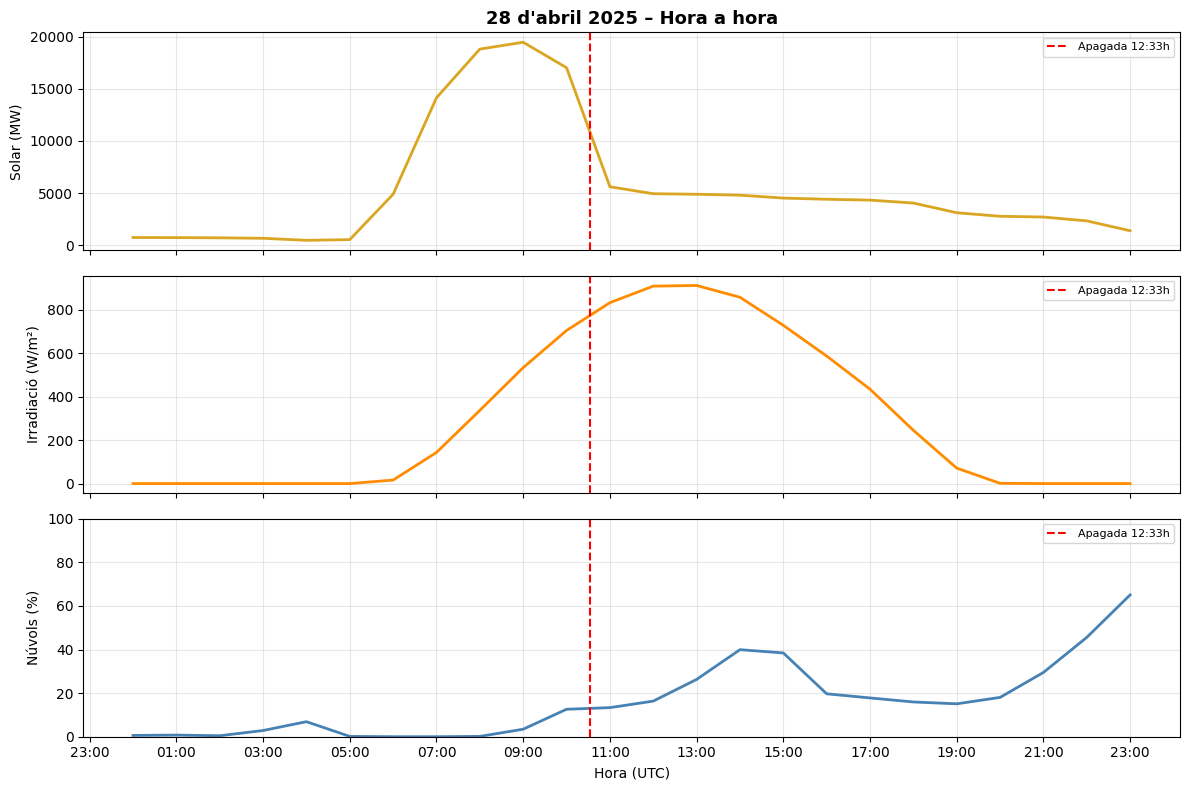

Gràfic 1 guardat ✓


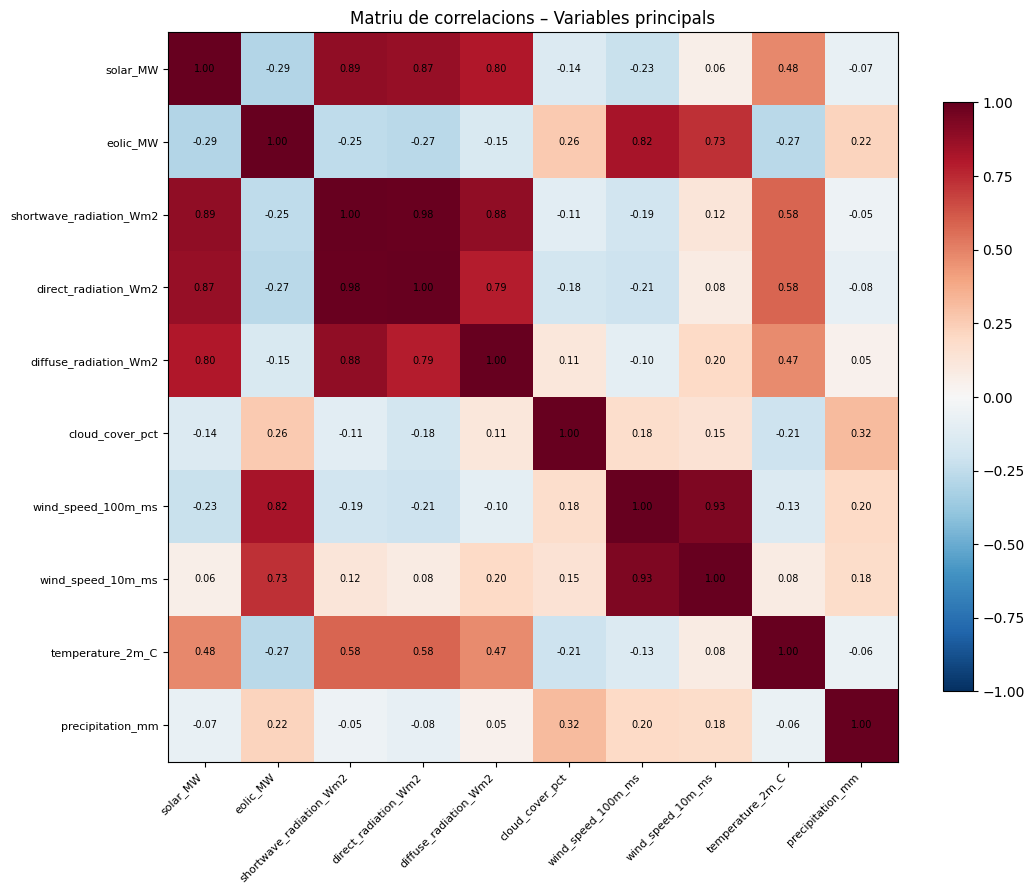

Gràfic 2 guardat ✓


In [31]:
import matplotlib.pyplot as plt

# ── Gràfic 1: 28 d'abril hora a hora ────────────────────────────────────────
dia = '2025-04-28'
mask = df.index.date == pd.Timestamp(dia).date()
dz = df.loc[mask]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(dz.index, dz['solar_MW'], color='goldenrod', lw=2)
axes[0].set_ylabel('Solar (MW)')
axes[0].set_title('28 d\'abril 2025 – Hora a hora', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(dz.index, dz['shortwave_radiation_Wm2'], color='darkorange', lw=2)
axes[1].set_ylabel('Irradiació (W/m²)')
axes[1].grid(alpha=0.3)

axes[2].plot(dz.index, dz['cloud_cover_pct'], color='steelblue', lw=2)
axes[2].set_ylabel('Núvols (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(alpha=0.3)

apagada_utc = pd.Timestamp('2025-04-28 10:33:00', tz='UTC')
for ax in axes:
    ax.axvline(apagada_utc, color='red', ls='--', lw=1.5, label='Apagada 12:33h')
    ax.legend(loc='upper right', fontsize=8)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xlabel('Hora (UTC)')
plt.tight_layout()
plt.savefig(r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\apagada_28abril_horari.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Gràfic 1 guardat ✓')

# ── Gràfic 2: Matriu de correlacions completa ────────────────────────────────
vars_corr = ['solar_MW', 'eolic_MW',
             'shortwave_radiation_Wm2', 'direct_radiation_Wm2',
             'diffuse_radiation_Wm2', 'cloud_cover_pct',
             'wind_speed_100m_ms', 'wind_speed_10m_ms',
             'temperature_2m_C', 'precipitation_mm']

corr = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Matriu de correlacions – Variables principals', fontsize=12)
plt.tight_layout()
plt.savefig(r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\matriu_correlacions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Gràfic 2 guardat ✓')

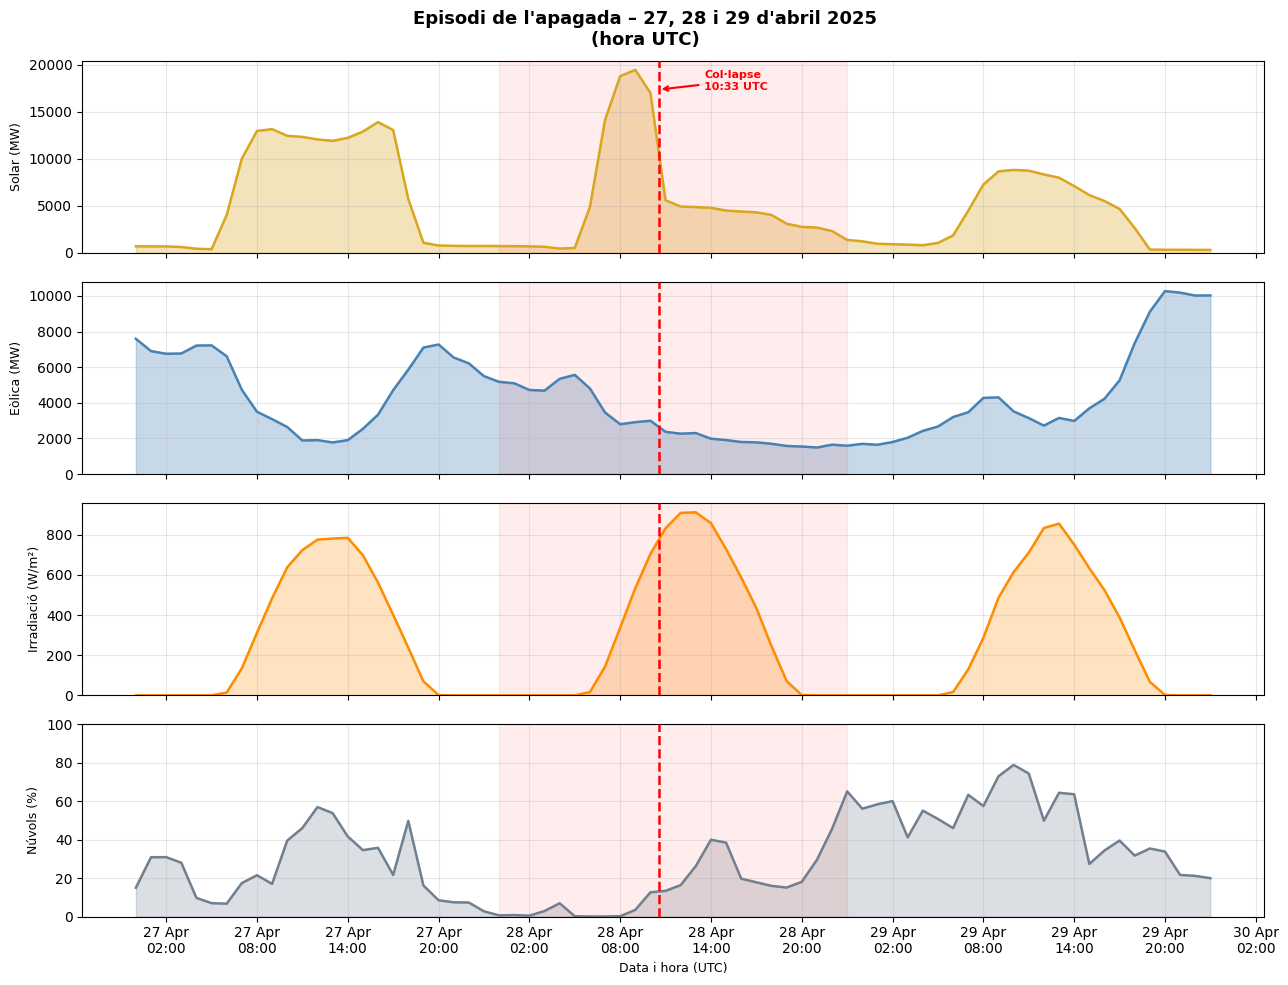

Figura guardada: zoom_apagada_tfg.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Tres dies: 27, 28 i 29 d'abril
zoom_ini = pd.Timestamp('2025-04-27', tz='UTC')
zoom_fi  = pd.Timestamp('2025-04-29 23:00:00', tz='UTC')
dz = df.loc[zoom_ini:zoom_fi]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Episodi de l\'apagada – 27, 28 i 29 d\'abril 2025\n(hora UTC)',
             fontsize=13, fontweight='bold', y=0.98)

# ── Panell 1: Solar MW ───────────────────────────────────────────────────────
axes[0].fill_between(dz.index, dz['solar_MW'], alpha=0.3, color='goldenrod')
axes[0].plot(dz.index, dz['solar_MW'], color='goldenrod', lw=1.8)
axes[0].set_ylabel('Solar (MW)', fontsize=9)
axes[0].set_ylim(bottom=0)
axes[0].grid(alpha=0.3)

# ── Panell 2: Eòlica MW ──────────────────────────────────────────────────────
axes[1].fill_between(dz.index, dz['eolic_MW'], alpha=0.3, color='steelblue')
axes[1].plot(dz.index, dz['eolic_MW'], color='steelblue', lw=1.8)
axes[1].set_ylabel('Eòlica (MW)', fontsize=9)
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)

# ── Panell 3: Irradiació ─────────────────────────────────────────────────────
axes[2].fill_between(dz.index, dz['shortwave_radiation_Wm2'], alpha=0.25, color='darkorange')
axes[2].plot(dz.index, dz['shortwave_radiation_Wm2'], color='darkorange', lw=1.8)
axes[2].set_ylabel('Irradiació (W/m²)', fontsize=9)
axes[2].set_ylim(bottom=0)
axes[2].grid(alpha=0.3)

# ── Panell 4: Cobertura de núvols ────────────────────────────────────────────
axes[3].fill_between(dz.index, dz['cloud_cover_pct'], alpha=0.25, color='slategray')
axes[3].plot(dz.index, dz['cloud_cover_pct'], color='slategray', lw=1.8)
axes[3].set_ylabel('Núvols (%)', fontsize=9)
axes[3].set_ylim(0, 100)
axes[3].grid(alpha=0.3)

# ── Línia apagada i ombrejat del dia 28 ─────────────────────────────────────
apagada_utc = pd.Timestamp('2025-04-28 10:33:00', tz='UTC')
dia28_ini   = pd.Timestamp('2025-04-28 00:00:00', tz='UTC')
dia28_fi    = pd.Timestamp('2025-04-28 23:00:00', tz='UTC')

for ax in axes:
    # Ombrejat suau del dia 28
    ax.axvspan(dia28_ini, dia28_fi, alpha=0.07, color='red')
    # Línia del col·lapse
    ax.axvline(apagada_utc, color='red', ls='--', lw=1.8, zorder=5)

# Anotació només al primer panell
axes[0].annotate('Col·lapse\n10:33 UTC',
    xy=(apagada_utc, axes[0].get_ylim()[1] * 0.85),
    xytext=(apagada_utc + pd.Timedelta('3h'), axes[0].get_ylim()[1] * 0.85),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=8, color='red', fontweight='bold')

# ── Eix X ───────────────────────────────────────────────────────────────────
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=6))
axes[3].set_xlabel('Data i hora (UTC)', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\zoom_apagada_tfg.png',
            dpi=180, bbox_inches='tight')
plt.show()
print('Figura guardada: zoom_apagada_tfg.png')